# 02 · RFM Analysis & Customer Segmentation

**Goal:** score every customer on three behaviours and group them into named segments that marketing/finance can act on.

> 📘 **What is RFM?** A classic, explainable customer-value framework (used in retail, banking and credit cards):
> - **R**ecency: *how many days since the customer last bought?* Lower = better. Recent customers are more likely to buy again.
> - **F**requency: *how many separate orders (invoices) have they placed?* Higher = more engaged.
> - **M**onetary: *how much have they spent in total?* Higher = more valuable.
>
> **Why banks care:** the same idea applies to card spend, account activity, or loan repayment behaviour. It's a quick, transparent way to prioritise customers *before* building complex ML models. Explainability matters a lot in regulated industries like banking.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGS = ROOT / "reports" / "figures"
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.float_format", "{:,.2f}".format)

sales = pd.read_parquet(PROCESSED / "sales_clean.parquet")
cust_sales = sales[sales["HasCustomer"]].copy()
print(f"{len(cust_sales):,} rows for {cust_sales['CustomerID'].nunique():,} identified customers")

776,531 rows for 5,852 identified customers


## 1. Compute raw R, F, M per customer
**Snapshot date:** we pretend "today" is the day after the last transaction (10-Dec-2011). Recency is measured from there.

In [2]:
snapshot = cust_sales["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot.date())

rfm = cust_sales.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda d: (snapshot - d.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
    FirstPurchase=("InvoiceDate", "min"),
    LastPurchase=("InvoiceDate", "max"),
    Country=("Country", lambda c: c.mode().iat[0]),
)
rfm.describe(percentiles=[.25, .5, .75, .95]).T

Snapshot date: 2011-12-10


,count,mean,min,25%,50%,75%,95%,max,std
Recency,"5,852.00",199.80,0.00,25.00,95.00,379.00,623.00,738.00,208.54
Frequency,"5,852.00",6.25,1.00,1.00,3.00,7.00,20.00,373.00,12.75
Monetary,"5,852.00","2,862.87",2.90,339.24,855.58,"2,237.29","9,140.37","580,987.04","14,067.84"
FirstPurchase,5852,2010-08-23 00:13:51.725905,2009-12-01 07:45:00,2010-02-11 09:44:00,2010-06-28 13:35:30,2011-02-01 11:46:00,2011-10-19 23:13:33,2011-12-09 12:16:00,NaN
LastPurchase,5852,2011-05-23 17:52:33.178400,2009-12-01 10:49:00,2010-11-25 15:47:45,2011-09-05 15:18:00,2011-11-14 12:50:30,2011-12-06 11:35:15,2011-12-09 12:50:00,NaN


**Observation:** all three are **heavily right-skewed** (mean ≫ median, huge max). That's why we score with **quantiles** (ranks) instead of raw values: one giant wholesaler shouldn't squash everyone else into the same bucket.

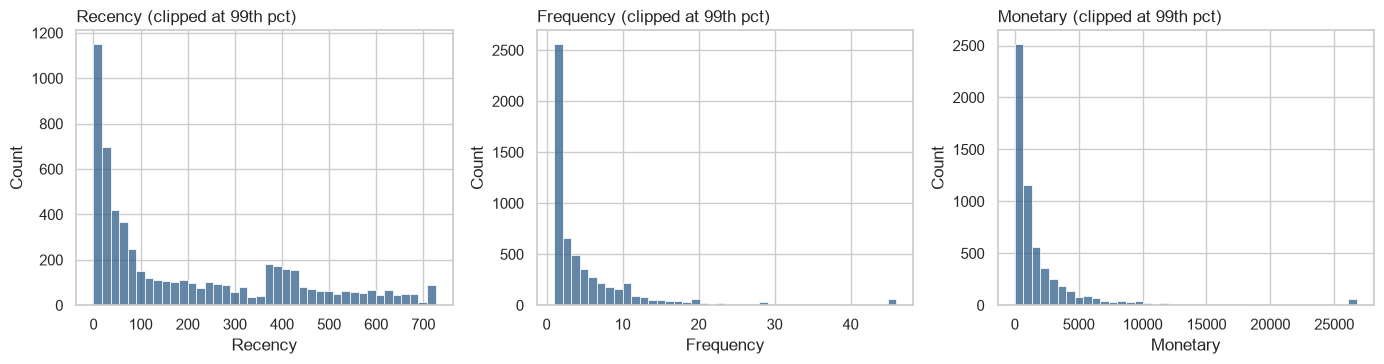

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col].clip(upper=rfm[col].quantile(.99)), bins=40, ax=ax, color="#2F5D8A")
    ax.set_title(f"{col} (clipped at 99th pct)", loc="left")
plt.tight_layout(); plt.savefig(FIGS / "02_rfm_distributions.png", dpi=150); plt.show()

## 2. Score R, F, M from 1 to 5 using quintiles
- `pd.qcut` splits customers into 5 equal-sized groups (quintiles).
- **Recency is reversed:** the most recent 20% get score **5**.
- For Frequency we rank first (`rank(method="first")`) because many customers have exactly 1 order, and ties would break `qcut`.

In [4]:
rfm["R"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM_Score"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)
rfm["RFM_Total"] = rfm[["R", "F", "M"]].sum(axis=1)
rfm.head()

,Recency,Frequency,Monetary,FirstPurchase,LastPurchase,Country,R,F,M,RFM_Score,RFM_Total
CustomerID,,,,,,,,,,,
12346,529,2,169.36,2010-03-02 13:08:00,2010-06-28 13:53:00,United Kingdom,1,2,1,121,4
12347,2,8,"4,921.53",2010-10-31 14:20:00,2011-12-07 15:52:00,Iceland,5,4,5,545,14
12348,75,5,"1,658.40",2010-09-27 14:59:00,2011-09-25 13:13:00,Finland,3,4,4,344,11
12349,18,3,"3,678.69",2010-04-29 13:20:00,2011-11-21 09:51:00,Italy,5,3,5,535,13
12350,310,1,294.40,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,2,1,2,212,5


**Quick check:** are F and M telling the same story? If they're strongly correlated, we can segment on **R × F** (a 5×5 grid) and M adds little extra. That is the standard industry segmentation grid.

In [5]:
print("Spearman correlation between scores:")
rfm[["R", "F", "M"]].corr(method="spearman")

Spearman correlation between scores:


,R,F,M
R,1.00,0.52,0.48
F,0.52,1.00,0.81
M,0.48,0.81,1.00


## 3. Map scores to named business segments
We use the widely-used **R-F segment grid**. Each segment gets a name a marketing manager instantly understands:

| Segment | Meaning | R | F |
|---|---|---|---|
| **Champions** | Bought recently, buy often | 5 | 4-5 |
| **Loyal Customers** | Buy regularly | 3-4 | 4-5 |
| **Potential Loyalists** | Recent, moderate frequency | 4-5 | 2-3 |
| **New Customers** | Very recent first purchase | 5 | 1 |
| **Promising** | Recent, low frequency | 4 | 1 |
| **Need Attention** | Average on both | 3 | 3 |
| **About to Sleep** | Slipping, low frequency | 3 | 1-2 |
| **At Risk** | Used to buy often, not recently | 1-2 | 3-4 |
| **Can't Lose Them** | Were top buyers, gone quiet | 1-2 | 5 |
| **Hibernating** | Long gone, rarely bought | 1-2 | 1-2 |

In [6]:
segment_map = {
    r"[1-2][1-2]": "Hibernating",
    r"[1-2][3-4]": "At Risk",
    r"[1-2]5": "Can't Lose Them",
    r"3[1-2]": "About to Sleep",
    r"33": "Need Attention",
    r"[3-4][4-5]": "Loyal Customers",
    r"41": "Promising",
    r"51": "New Customers",
    r"[4-5][2-3]": "Potential Loyalists",
    r"5[4-5]": "Champions",
}
rfm["Segment"] = (rfm["R"].astype(str) + rfm["F"].astype(str)).replace(segment_map, regex=True)
rfm["Segment"].value_counts()

Segment
Hibernating            1512
Loyal Customers        1132
Champions               850
At Risk                 756
Potential Loyalists     712
About to Sleep          382
Need Attention          268
Promising               111
Can't Lose Them          72
New Customers            57
Name: count, dtype: int64

## 4. Segment profiles: the "so what?"
A segmentation is only useful if segments are **different** and **actionable**.

In [7]:
total_rev = rfm["Monetary"].sum()
profile = (rfm.groupby("Segment")
           .agg(Customers=("R", "size"), AvgRecency=("Recency", "mean"), AvgFrequency=("Frequency", "mean"),
                AvgMonetary=("Monetary", "mean"), Revenue=("Monetary", "sum"))
           .assign(**{"% Customers": lambda d: d.Customers / d.Customers.sum() * 100,
                      "% Revenue": lambda d: d.Revenue / total_rev * 100})
           .sort_values("Revenue", ascending=False))
profile

,Customers,AvgRecency,AvgFrequency,AvgMonetary,Revenue,% Customers,% Revenue
Segment,,,,,,,
Champions,850,8.30,19.06,"10,389.50","8,831,071.89",14.52,52.71
Loyal Customers,1132,66.60,9.72,"4,041.53","4,575,008.65",19.34,27.31
At Risk,756,371.20,3.90,"1,279.31","967,160.93",12.92,5.77
Potential Loyalists,712,25.25,2.58,905.92,"645,016.61",12.17,3.85
Hibernating,1512,456.03,1.25,419.70,"634,581.25",25.84,3.79
Can't Lose Them,72,326.83,16.36,"6,991.74","503,405.14",1.23,3.00
Need Attention,268,112.31,3.14,"1,259.57","337,564.23",4.58,2.01
About to Sleep,382,105.24,1.36,536.81,"205,062.23",6.53,1.22
Promising,111,38.29,1.00,315.63,"35,035.12",1.90,0.21


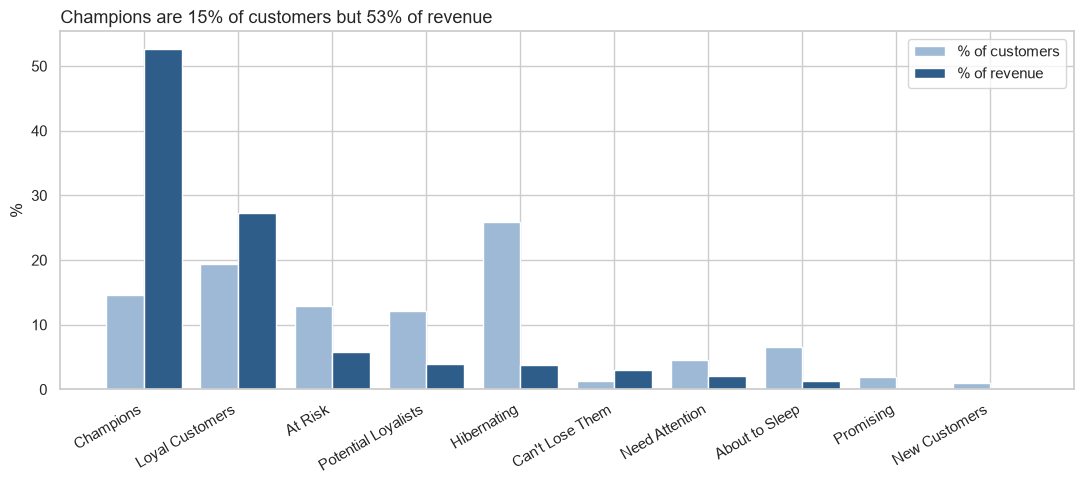

In [8]:
order = profile.index
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(order)); w = 0.4
ax.bar(x - w/2, profile["% Customers"], w, label="% of customers", color="#9DB9D5")
ax.bar(x + w/2, profile["% Revenue"], w, label="% of revenue", color="#2F5D8A")
ax.set_xticks(x, order, rotation=30, ha="right"); ax.set_ylabel("%")
champ = profile.loc["Champions"]
ax.set_title(f"Champions are {champ['% Customers']:.0f}% of customers but {champ['% Revenue']:.0f}% of revenue",
             loc="left", fontsize=13)
ax.legend(); plt.tight_layout(); plt.savefig(FIGS / "02_segment_share.png", dpi=150); plt.show()

### The R × F grid (heatmap of average spend)
Each cell = customers with that R and F score. Colour = average spend. Top-right = best customers.

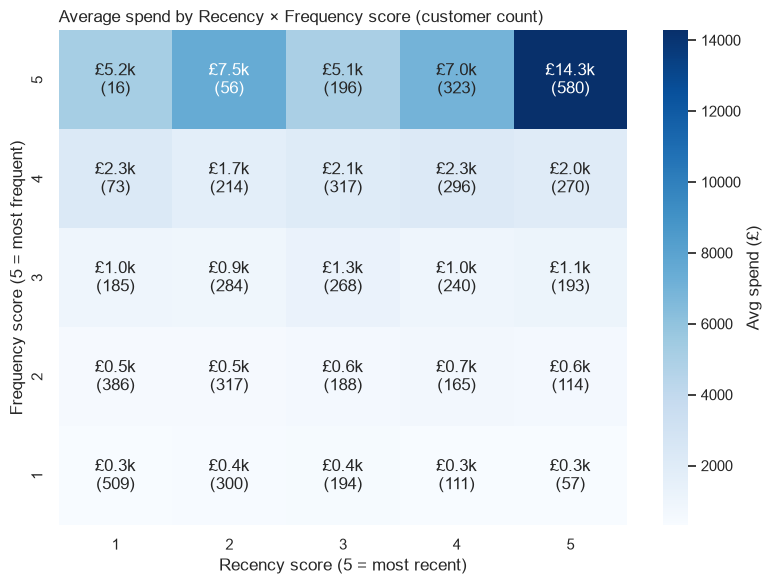

In [9]:
grid = rfm.pivot_table(index="F", columns="R", values="Monetary", aggfunc="mean").sort_index(ascending=False)
counts = rfm.pivot_table(index="F", columns="R", values="Monetary", aggfunc="size").sort_index(ascending=False)
annot = grid.map(lambda v: f"£{v/1e3:,.1f}k") + "\n(" + counts.astype(str) + ")"
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(grid, annot=annot, fmt="", cmap="Blues", ax=ax, cbar_kws={"label": "Avg spend (£)"})
ax.set_title("Average spend by Recency × Frequency score (customer count)", loc="left")
ax.set_xlabel("Recency score (5 = most recent)"); ax.set_ylabel("Frequency score (5 = most frequent)")
plt.tight_layout(); plt.savefig(FIGS / "02_rf_grid.png", dpi=150); plt.show()

## 5. Recommended actions per segment
This is what turns analysis into **business value**, which is exactly the "Commercial Insight & Advisory" mindset in the JD.

In [10]:
actions = pd.DataFrame({
    "Segment": ["Champions", "Loyal Customers", "Potential Loyalists", "New Customers", "Promising",
                "Need Attention", "About to Sleep", "At Risk", "Can't Lose Them", "Hibernating"],
    "Priority": ["Retain", "Retain", "Grow", "Grow", "Grow", "Re-engage", "Re-engage", "Win back", "Win back", "Low cost"],
    "Recommended action": [
        "VIP / loyalty tier, early access to new ranges, ask for referrals. No discounts needed.",
        "Upsell higher-value ranges, volume-based rewards, account manager for top ones.",
        "Membership / loyalty sign-up, personalised recommendations to raise frequency.",
        "Onboarding journey, welcome offer on 2nd order to build the habit.",
        "Brand awareness, time-limited offer to trigger a repeat purchase.",
        "Personalised reminders based on past purchases, limited-time offers.",
        "Reactivation email with popular products; a small discount.",
        "Personalised win-back offer; survey to find out why they stopped.",
        "Highest-value churn risk: direct call from account manager, strong incentive.",
        "Low-cost automated campaigns only; don't overspend on reacquisition.",
    ],
})
actions = actions.merge(profile[["Customers", "% Revenue"]], left_on="Segment", right_index=True, how="left")
actions

,Segment,Priority,Recommended action,Customers,% Revenue
0,Champions,Retain,"VIP / loyalty tier, early access to new ranges...",850,52.71
1,Loyal Customers,Retain,"Upsell higher-value ranges, volume-based rewar...",1132,27.31
2,Potential Loyalists,Grow,"Membership / loyalty sign-up, personalised rec...",712,3.85
3,New Customers,Grow,"Onboarding journey, welcome offer on 2nd order...",57,0.12
4,Promising,Grow,"Brand awareness, time-limited offer to trigger...",111,0.21
5,Need Attention,Re-engage,Personalised reminders based on past purchases...,268,2.01
6,About to Sleep,Re-engage,Reactivation email with popular products; a sm...,382,1.22
7,At Risk,Win back,Personalised win-back offer; survey to find ou...,756,5.77
8,Can't Lose Them,Win back,Highest-value churn risk: direct call from acc...,72,3.00
9,Hibernating,Low cost,Low-cost automated campaigns only; don't overs...,1512,3.79


### Revenue at risk
"At Risk" + "Can't Lose Them" customers **used to** be valuable but have gone quiet. Their historic spend is a proxy for revenue we could lose.

In [11]:
at_risk = rfm[rfm["Segment"].isin(["At Risk", "Can't Lose Them"])]
print(f"{len(at_risk):,} customers ({len(at_risk)/len(rfm):.0%}) with historic spend of "
      f"£{at_risk['Monetary'].sum():,.0f} ({at_risk['Monetary'].sum()/total_rev:.0%} of customer revenue) are at risk.")

828 customers (14%) with historic spend of £1,470,566 (9% of customer revenue) are at risk.


In [12]:
rfm.reset_index().to_parquet(PROCESSED / "rfm.parquet", index=False)
actions.to_csv(PROCESSED / "segment_actions.csv", index=False)
print("Saved rfm.parquet and segment_actions.csv")

Saved rfm.parquet and segment_actions.csv


## ✅ Key takeaways
1. RFM turns raw transactions into **3 interpretable numbers per customer**. Quantile scoring handles the heavy skew.
2. F and M are strongly correlated, so the **R × F grid** captures most of the story.
3. A small group of **Champions** drives a disproportionate share of revenue → retention priority.
4. **At Risk / Can't Lose Them** customers represent quantifiable revenue at risk → targeted win-back.

**Limitation to mention in interviews:** RFM is descriptive (looks backward) and the segment cut-offs are rule-based. Notebook 03 lets the data find natural groups (K-Means), and notebook 05 *predicts* who will churn.